
# PRACTICA **2**

# AGRUPAMIENTO (CLUSTERING)
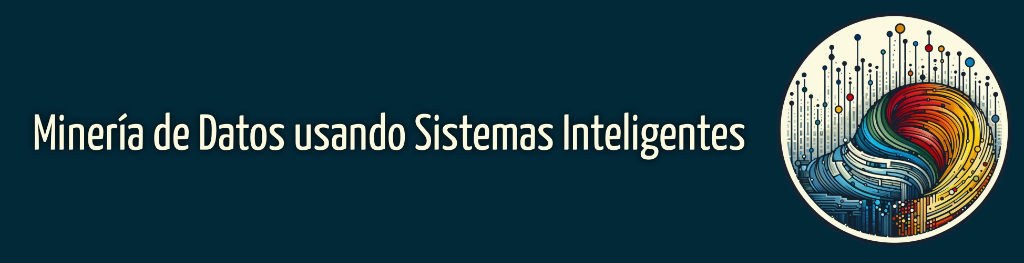

**Ejercicio a entregar: 2 (todos los incisos).**

***Material de Lectura: Capítulo 16 del Libro Introducción a la Minería de Datos de Hernández Orallo***



In [87]:
#HELPER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

_ = [pd, np, plt, sns, KMeans, silhouette_score, davies_bouldin_score, StandardScaler]

In [88]:
base_url = "https://raw.githubusercontent.com/midusi/learning-datasets/refs/heads/main/"
df_simple = pd.read_csv(base_url+"2d_simple.csv")
df_complex = pd.read_csv(base_url+"2d_complex.csv")

# 1. Funciones de distancia y cálculo de centroides

a) Calcular la distancia euclídea entre los puntos **p1 = (2,-2, 2, -4)** y **p2 = (3, 0, 6, -2)**. Calcular también la distancia euclídea al cuadrado.


In [89]:
p1 = np.array([2, -2, 2, -4])
p2 = np.array([3, 0, 6, -2])

dist_sq = np.sum((p1 - p2) ** 2)
dist = np.sqrt(dist_sq)

print("Distancia euclídea:", dist)
print("Distancia euclídea al cuadrado:", dist_sq)

Distancia euclídea: 5.0
Distancia euclídea al cuadrado: 25



b) Dados los centroides **c1** y **c2** y el punto **x1**, calcular las distancias euclídea del punto **x1** a **c1** y **c2**. Luego indicar el centroide más cercano a **x1**. Calcular también la distancia euclídea al cuadrado.



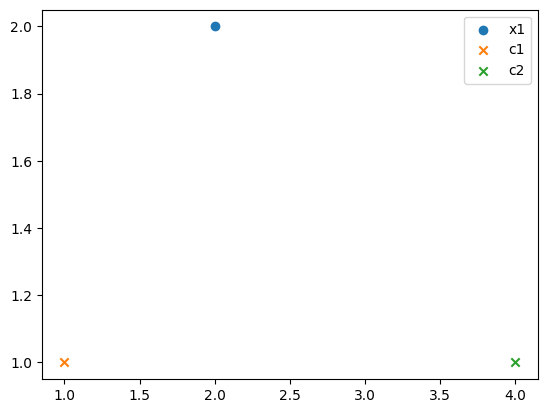

In [90]:
#HELPER
x1 = np.array([2, 2])
c1 = np.array([1, 1])
c2 = np.array([4, 1])

plt.scatter(x1[0], x1[1], label='x1')
plt.scatter(c1[0], c1[1], marker=MarkerStyle("x"), label='c1')
plt.scatter(c2[0], c2[1], marker=MarkerStyle("x"), label='c2')
plt.legend()


In [91]:
dist_x1_c1_sq = np.sum((x1 - c1) ** 2)
dist_x1_c2_sq = np.sum((x1 - c2) ** 2)

dist_x1_c1 = np.sqrt(dist_x1_c1_sq)
dist_x1_c2 = np.sqrt(dist_x1_c2_sq)

closest_centroid = "c1" if dist_x1_c1 < dist_x1_c2 else "c2"

print(f"Distancia euclídea x1 a c1: {dist_x1_c1}")
print(f"Distancia euclídea x1 a c2: {dist_x1_c2}")
print(f"Distancia euclídea al cuadrado x1 a c1: {dist_x1_c1_sq}")
print(f"Distancia euclídea al cuadrado x1 a c2: {dist_x1_c2_sq}")
print(f"Centroide más cercano a x1: {closest_centroid}")

Distancia euclídea x1 a c1: 1.4142135623730951
Distancia euclídea x1 a c2: 2.23606797749979
Distancia euclídea al cuadrado x1 a c1: 2
Distancia euclídea al cuadrado x1 a c2: 5
Centroide más cercano a x1: c1


c) La distancia de Manhattan entre dos puntos **A** y **B** se define como **d(A,B) = Σi |Ai-Bi|**, donde Ai y Bi son los valores de los puntos. Repetir los puntos **a-b** con la distancia de Manhattan.

In [92]:
dist_manhattan = np.sum(np.abs(p1 - p2))

dist_x1_c1_manhattan = np.sum(np.abs(x1 - c1))
dist_x1_c2_manhattan = np.sum(np.abs(x1 - c2))

closest_centroid_manhattan = "c1" if dist_x1_c1_manhattan < dist_x1_c2_manhattan else "c2"

print("Distancia Manhattan p1 a p2:", dist_manhattan)
print("Distancia Manhattan x1 a c1:", dist_x1_c1_manhattan)
print("Distancia Manhattan x1 a c2:", dist_x1_c2_manhattan)
print("Centroide más cercano a x1 (Manhattan):", closest_centroid_manhattan)

Distancia Manhattan p1 a p2: 9
Distancia Manhattan x1 a c1: 2
Distancia Manhattan x1 a c2: 3
Centroide más cercano a x1 (Manhattan): c1


d) ¿Qué relación encuentra entre la distancia Euclídea y la Euclídea al cuadrado, para las distancias entre x1 y c1 y entre x1 y c2?


| Puntos | Distancia Euclídea | Distancia Euclídea al cuadrado | Distancia de Manhattan |
| :--- | :--- | :--- | :--- |
| **p1, p2** | 5 | 25 | 9 |
| **x1, c1** | 1.4 | 2 | 2 |
| **x1, c2** | 2.2 | 5 | 3 |

La relacion entre las distancias es, como su nombre lo indica, el cuadrado. 

e) Dados los datos x1 = (2,3), x2 = (-2,2) y x3 = (6,-14) calcular el centroide C de los mismos. Dibujar los datos y el centroide C en un plano cartesiano.

Centroide C: [2. 6.]


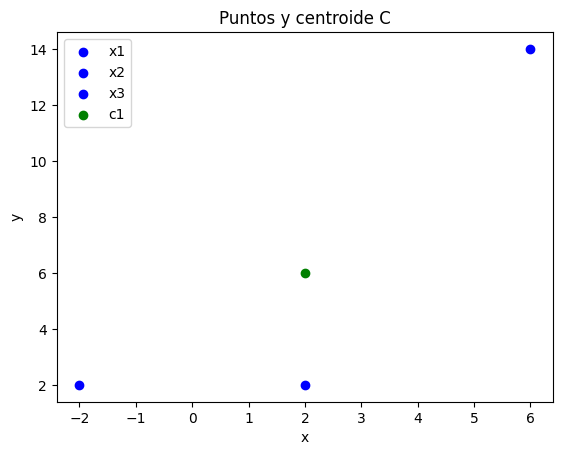

In [93]:
x1 = np.array([2, 2])
x2 = np.array([-2, 2])
x3 = np.array([6, 14])

c1 = (x1 + x2 + x3) / 3

print("Centroide C:", c1)

plt.scatter(x1[0], x1[1], label='x1', color='blue')
plt.scatter(x2[0], x2[1], label='x2', color='blue')
plt.scatter(x3[0], x3[1], label='x3', color='blue')
plt.scatter(c1[0], c1[1], label='c1', color='green')


plt.xlabel('x')
plt.ylabel('y')
plt.title('Puntos y centroide C')
plt.legend()
plt.show()

# 2. Algoritmo K-medias

Nota: Es obligatorio utilizar el formato de tabla indicado ejercicio para la entrega. Incluir las tablas y respuestas al principio, y al final un anexo con las cuentas de cada inciso. Utilizar una precisión de a lo sumo 2 decimales cuando sea necesario. No utilizar fracciones para expresar los resultados. Si las distancias de un ejemplo a los centroides son iguales, elegir un centroide de forma aleatoria.

a. Dados los datos x1, x2, x3 y x4, y los centroides iniciales c1 y c2, dibujar sus posiciones en el plano X-Y.

Datos:
* x1=(2,0)
* x2=(1,2)
* x3=(3,4)
* x4=(4,4).

Centroides iniciales:

* c1=(3,3)
* c2=(4,3).


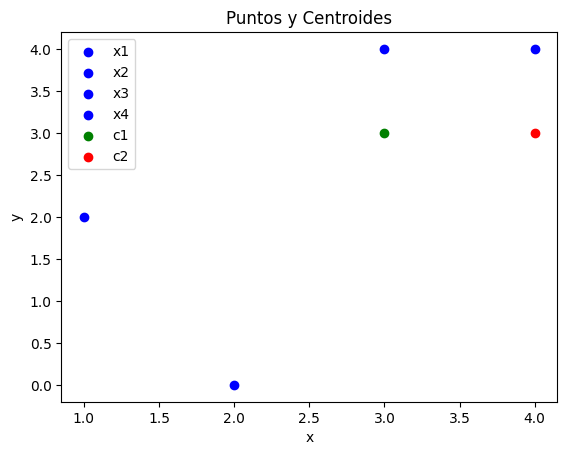

In [94]:
x1 = np.array([2, 0])
x2 = np.array([1, 2])
x3 = np.array([3, 4])
x4 = np.array([4, 4])

c1 = np.array([3, 3])
c2 = np.array([4, 3])

plt.scatter(x1[0], x1[1], label='x1', color='blue')
plt.scatter(x2[0], x2[1], label='x2', color='blue')
plt.scatter(x3[0], x3[1], label='x3', color='blue')
plt.scatter(x4[0], x4[1], label='x4', color='blue')
plt.scatter(c1[0], c1[1], label='c1', color='green')
plt.scatter(c2[0], c2[1], label='c2', color='red')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Puntos y Centroides')
plt.legend()
plt.show()


b. Realizar tres iteraciones del algoritmo k-medias para obtener un clustering con **k=2** grupos, y calcular el valor final de los centroides.


Utilizar **distancia euclídea al cuadrado**. Utilice el siguiente formato de tabla para presentar los resultados:


| Puntos | Dist a c1 | Dist a c2 | Centroide | Dist a c1 | Dist a c2 | Centroide | Dist a c1 | Dist a c2 | Centroide |
|:---|:---|:---|:---|:---|:---|:---|:---|:---|:---|
| . | **Iteración 1** | . |.  | **Iteración 2** | . |. | **Iteración 3** |.  |.  |
| **x1 = (2,0)** |  |  |  |  |  |  |  |  |  |
| **x2 = (1,2)** |  |  |  |  |  |  |  |  |  |
| **x3 = (3,4)** |  |  |  |  |  |  |  |  |  |
| **x4 = (4,4)** |  |  |  |  |  |  |  |  |  |
| **Nuevos Centros** | **c1:** | **c2:** |  | **c1:** | **c2:** |  | **c1:** | **c2:** |  |


In [9]:
def distancia2(p, c): return np.sum((p - c) ** 2)

X = np.array([x1, x2, x3, x4])
centroides = np.array([c1, c2])
resultados = []

for iteracion in range(1, 4):
    filas = []
    clusters = {0: [], 1: []}
    for i, punto in enumerate(X):
        d1 = distancia2(punto, centroides[0])
        d2 = distancia2(punto, centroides[1])
        cluster = "c1" if d1 <= d2 else "c2"
        if cluster == "c1":
            clusters[0].append(punto)
        else:
            clusters[1].append(punto)
        filas.append({
            "Punto": f"x{i+1} = {tuple(punto)}",
            "Dist a c1": d1,
            "Dist a c2": d2,
            "Centroide": cluster
        })
    nuevos_centroides = []
    for k in range(2):
        if len(clusters[k]) > 0:
            nuevo = np.mean(clusters[k], axis=0)
        else:
            nuevo = centroides[k]
        nuevos_centroides.append(nuevo)
    centroides = np.array(nuevos_centroides)
    df_iter = pd.DataFrame(filas)

    print("\n==============================")
    print(f"ITERACIÓN {iteracion}")
    print("==============================")
    print(df_iter)

    print("\nNuevos centroides:")
    print(f"c1 = {centroides[0]}")
    print(f"c2 = {centroides[1]}")

    resultados.append(df_iter)



ITERACIÓN 1
                             Punto  Dist a c1  Dist a c2 Centroide
0  x1 = (np.int64(2), np.int64(0))         10         13        c1
1  x2 = (np.int64(1), np.int64(2))          5         10        c1
2  x3 = (np.int64(3), np.int64(4))          1          2        c1
3  x4 = (np.int64(4), np.int64(4))          2          1        c2

Nuevos centroides:
c1 = [2. 2.]
c2 = [4. 4.]

ITERACIÓN 2
                             Punto  Dist a c1  Dist a c2 Centroide
0  x1 = (np.int64(2), np.int64(0))        4.0       20.0        c1
1  x2 = (np.int64(1), np.int64(2))        1.0       13.0        c1
2  x3 = (np.int64(3), np.int64(4))        5.0        1.0        c2
3  x4 = (np.int64(4), np.int64(4))        8.0        0.0        c2

Nuevos centroides:
c1 = [1.5 1. ]
c2 = [3.5 4. ]

ITERACIÓN 3
                             Punto  Dist a c1  Dist a c2 Centroide
0  x1 = (np.int64(2), np.int64(0))       1.25      18.25        c1
1  x2 = (np.int64(1), np.int64(2))       1.25      10.25     

In [10]:
xi = np.array([x1, x2, x3, x4])
ci = np.array([c1, c2])

kmeans = KMeans(
    n_clusters=2,
    init=ci,
    n_init=1,
    max_iter=3,
    random_state=0
)

kmeans.fit(xi)

print("Centroides sklearn:")
print(kmeans.cluster_centers_)

print("\nLabels:")
print(kmeans.labels_)

Centroides sklearn:
[[1.5 1. ]
 [3.5 4. ]]

Labels:
[0 0 1 1]


c. Si realizaran más iteraciones del algoritmo ¿cambiarían las asignaciones? ¿y los centros? ¿por qué?

Si se realizaran más iteraciones del algoritmo de k-medias, las asignaciones y los centros solo cambiarían si todavía existieran puntos que, luego de recalcular los centroides, quedaran más cerca de otro grupo. En ese caso, el algoritmo continuaría modificando tanto las asignaciones como las posiciones de los centros hasta encontrar una configuración más estable.

En cambio, si en la última iteración ningún punto cambia de grupo y los centroides permanecen iguales, entonces realizar más iteraciones no produciría cambios. Esto ocurre porque el algoritmo ya alcanzó la convergencia, es decir, un estado estable donde repetir los pasos de asignación y actualización genera exactamente el mismo resultado.


d. Realice el mismo ejercicio que b., pero ahora con otros centroides iniciales: c1=(1,2), c2=(3,4).


In [11]:
c1 = np.array([1, 2])
c2 = np.array([3, 4])

xi = np.array([x1, x2, x3, x4])
ci = np.array([c1, c2])

kmeans = KMeans(
    n_clusters=2,
    init=ci,
    n_init=1,
    max_iter=3,
    random_state=0
)

kmeans.fit(xi)

print("Centroides sklearn:")
print(kmeans.cluster_centers_)

print("\nLabels:")
print(kmeans.labels_)

Centroides sklearn:
[[1.5 1. ]
 [3.5 4. ]]

Labels:
[0 0 1 1]




e. Realice el mismo ejercicio que b., pero ahora con un nuevo conjunto de centroides: c1=(2,3), c2=(2,-1).


In [12]:
c1 = np.array([2, 3])
c2 = np.array([2, -1])

xi = np.array([x1, x2, x3, x4])
ci = np.array([c1, c2])

kmeans = KMeans(
    n_clusters=2,
    init=ci,
    n_init=1,
    max_iter=3,
    random_state=0
)

kmeans.fit(xi)

print("Centroides sklearn:")
print(kmeans.cluster_centers_)

print("\nLabels:")
print(kmeans.labels_)

Centroides sklearn:
[[2.66666667 3.33333333]
 [2.         0.        ]]

Labels:
[1 0 0 0]


f. Indique cuáles de estas cosas pueden variar si se corre el algoritmo K-Medias con K=4 en un conjunto de datos fijo y se varían los valores de los centroides iniciales.

* Cantidad de iteraciones

* Valores de los centroides finales

* Cantidad de centroides

* Cantidad de grupos encontrados

* Cantidad de ejemplos por centroide/grupo

Pueden variar:

* **Cantidad de iteraciones:** distintos centroides iniciales pueden hacer que el algoritmo tarde más o menos en converger.
* **Valores de los centroides finales:** K-Means puede converger a distintos mínimos locales según la inicialización.
* **Cantidad de ejemplos por centroide/grupo:** al cambiar las asignaciones finales, también puede cambiar cuántos ejemplos quedan en cada grupo.

No pueden variar:

* **Cantidad de centroides:** siempre será (K=4), porque el valor de (K) está fijado.
* **Cantidad de grupos encontrados:** el algoritmo siempre genera 4 grupos, uno por cada centroide.


# 3. Clustering con KMedias. Validación del valor de k. Uso de métricas para evaluar agrupamientos.


En este ejercicio se busca utilizar dos índices distintos que pueden ayudar a elegir un buen valor de K para el agrupamiento. El archivo **2d_simple.csv** contiene 5000 filas, cada una con dos atributos numéricos, **x,y,** junto con el cluster original. Estos datos son sintéticos (generados artificialmente).

1.  Cargar el conjunto de datos.

2.  Dado que este conjunto de datos puede visualizarse en 2D, determinar **visualmente** la cantidad de clusters utilizando un gráfico de dispersión.

3.  Utilizando la clase [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) de Scikit-Learn realice un clustering de los datos. Evalúe el resultado con el índice promedio *Silhouette* con la función [sillhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html). El clustering debe realizarse con **k=2** y distancia **Euclídea**.

4.  Repita el punto 3 variando el valor de **k** (al menos con k=2,3,..,9)**.** Haga una tabla con el valor del índice *Silhouette* para cada valor de **k**. Con esa tabla, determine el valor de **k** óptimo ¿coincide con el valor que determinó en el punto 2? Recuerde que en el índice *Silhouette* es mejor si el valor es más alto.

5.  Repita el punto 4, pero ahora puntuando el resultado del clustering con *Davies-Bouldin* en lugar de *Silhouette*. Para ello utilizar la función [davies_bouldin_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html). Recuerde que el criterio Davies Bouldin es mejor cuando el valor es más bajo.

6. Genere una tabla como la siguiente para comparar:


| **k** | **Silhouette** | **Davies-Bouldin** |
| :--- | :--- | :--- |
| 2 | | |
| 3 | | |
| 4 | | |
| 5 | | |
| 6 | | |
| 7 | | |
| 8 | | |
| 9 | | |

**Cargar el Conjunto de Datos**

In [16]:
base_url = "https://raw.githubusercontent.com/midusi/learning-datasets/refs/heads/main/"
df_simple = pd.read_csv(base_url+"2d_simple.csv")
df_simple.head()

,x,y
0,11.518753,6.814413
1,6.746069,4.193922
2,10.994704,4.185808
3,9.443586,5.036560
4,8.189076,5.788035


**Determinar Visualmente los Clusters**

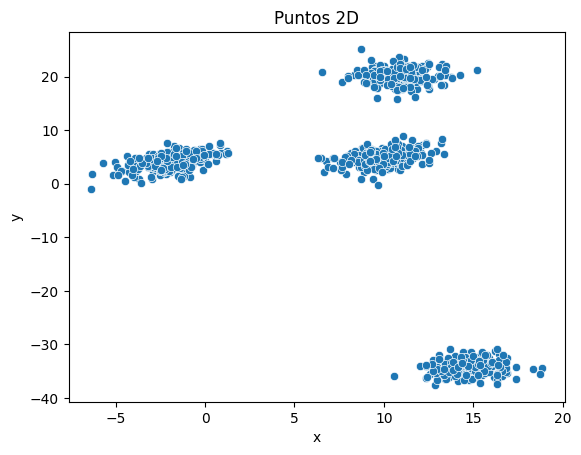

In [17]:
ax = sns.scatterplot(data=df_simple, x='x', y='y')
ax.set(title='Puntos 2D', xlabel='x', ylabel='y')
plt.show()

**Análisis por K-Medias**

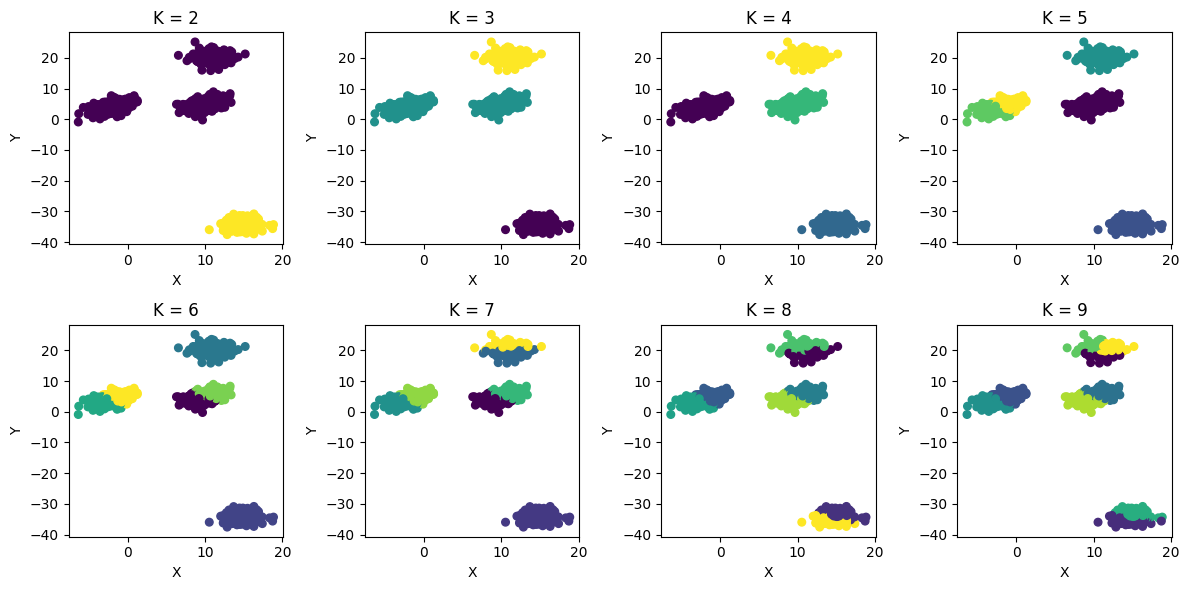

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, k in enumerate(range(2, 10)):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(df_simple)

    labels = kmeans.labels_
    centroides = kmeans.cluster_centers_

    axes[i].scatter(df_simple["x"], df_simple["y"], c=labels, cmap="viridis", s=30)

    axes[i].set_title(f"K = {k}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")

plt.tight_layout()
plt.show()

K = 2
Silhouette Score: 0.7934
Davies-Bouldin Index: 0.2443
K = 3
Silhouette Score: 0.7404
Davies-Bouldin Index: 0.3731
K = 4
Silhouette Score: 0.8373
Davies-Bouldin Index: 0.2295
K = 5
Silhouette Score: 0.7394
Davies-Bouldin Index: 0.4855
K = 6
Silhouette Score: 0.6353
Davies-Bouldin Index: 0.6893
K = 7
Silhouette Score: 0.5134
Davies-Bouldin Index: 0.8881
K = 8
Silhouette Score: 0.3586
Davies-Bouldin Index: 1.0664
K = 9
Silhouette Score: 0.3517
Davies-Bouldin Index: 1.0343


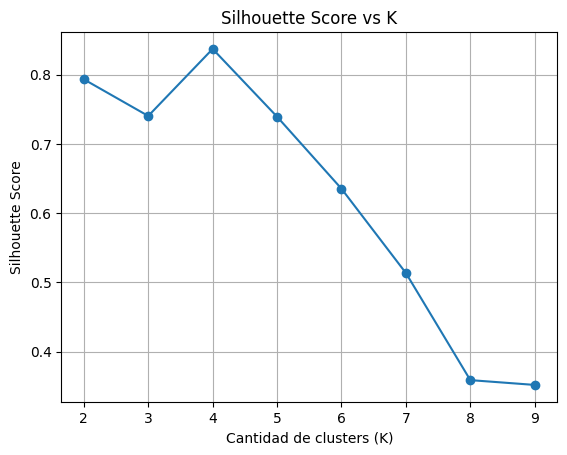

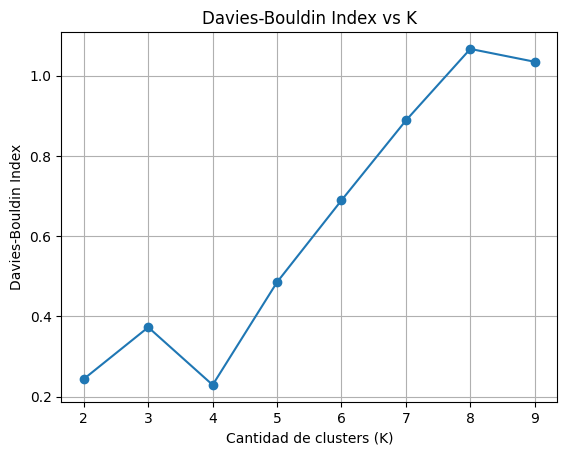

In [ ]:
ks = range(2, 10)

silhouette_scores = []
davies_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_simple)

    labels = kmeans.labels_

    sil = silhouette_score(df_simple, labels, metric="euclidean")
    db = davies_bouldin_score(df_simple, labels)

    silhouette_scores.append(sil)
    davies_scores.append(db)

    print(f"K = {k}")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies-Bouldin Index: {db:.4f}")


plt.figure()
plt.plot(ks, silhouette_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Cantidad de clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(ks, davies_scores, marker="o")
plt.title("Davies-Bouldin Index vs K")
plt.xlabel("Cantidad de clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.grid(True)
plt.show()

# 4. Características de Jugadores de Fútbol. Análisis de posiciones.

![](./img/futbol.png "asd")


El archivo **jugadores_2023.xlsx** contiene datos de atributos físicas y habilidades de jugadores de fútbol en varias posiciones. Este conjunto de datos es complejo, y por lo tanto no es trivial entender sus atributos, valores y las relaciones entre los mismos. El atributo `Best position` indica la posición en que el jugador se desempeña usualmente. Sus valores son:

-   **LB -** Defensor Izquierdo

-   **CB**-- Defensor Central

-   **RB** -- Defensor Derecho

-   **CDM**-- Mediocampista Defensivo Central

-   **LM -** Mediocampista Izquierdo

-   **CM** --Mediocampista Central

-   **RM** -- Mediocampista Derecho

-   **CAM** -- Mediocampista Atacante Central

-   **LW** -- Atacante Izquierdo

-   **CF** --Atacante Central

-   **RW** -- Atacante Derecho

-   **ST** --Atacante Goleador

Si bien los jugadores se agrupan tradicionalmente en base a su **posición**, queremos buscar un agrupamiento alternativo que surja naturalmente de sus características para entender mejor al conjunto de
datos. Además, de este modo podríamos motivar nuevas estrategias de juego o formas de organizar tácticas en base a roles que surjan espontáneamente.

In [42]:
#HELPER
df_fifa = pd.read_csv(base_url + "jugadores_2023.csv")

In [44]:
df_fifa.info()

<class 'pandas.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Known As                     18539 non-null  str  
 1   Full Name                    18539 non-null  str  
 2   Overall                      18539 non-null  int64
 3   Potential                    18539 non-null  int64
 4   Value(in Euro)               18539 non-null  int64
 5   Best Position                18539 non-null  str  
 6   Nationality                  18539 non-null  str  
 7   Age                          18539 non-null  int64
 8   Height(in cm)                18539 non-null  int64
 9   Weight(in kg)                18539 non-null  int64
 10  TotalStats                   18539 non-null  int64
 11  BaseStats                    18539 non-null  int64
 12  Club Name                    18539 non-null  str  
 13  Wage(in Euro)                18539 non-null  int64
 14  R

Utilice el algoritmo *K-medias* para agrupar los datos. Para ello:

a)  No incluya los atributos **posiciones** y ***nombre***.

b)  Decida qué atributos dejar para el agrupamiento y cuales quitar. Por ejemplo, el atributo **Club Name** es nominal, con lo cual será difícil de usar en el agrupamiento, pero además dará poca información, ya que hay muchísimos clubes distintos, y relativamente pocos jugadores por cada club.

c)  Transforme los atributos para poder aplicar K-Medias. Por ejemplo, el atributo **preferred foot (pie preferido)** es nominal, y debe ser convertido a un número para ser utilizado.

d)  Tenga en cuenta los rangos de valores de los atributos. ¿Es necesario normalizarlos?

Pruebe distintos valores de **k** (2,3,4,5). En base a cada valor:

e)  Analice los valores de los centroides ¿cómo podría caracterizar los grupos conseguidos? Tenga en cuenta características en común o diferencias entre ellos.\ Recuerde que no hay una respuesta *correcta*, ni tampoco un valor de **k** *correcto.* Cada agrupamiento nos da una perspectiva distinta de los datos.

| k | Descripción del agrupamiento |
| :--- | :--- |
| 2 | |
| 3 | |
| 4 | |
| 5 | |

f)  Observe el valor del atributo **posiciones** de los jugadores. ¿Cómo se compara con el agrupamiento obtenido en base a los datos? Realizar un gráfico de dispersión de la clase original (**posiciones)** vs el nro de cluster asignado para ver la cantidad de veces que se corresponden.

g)  Una hipótesis razonable es que la distribución de habilidades varíe con las generaciones, es decir, que los jugadores jóvenes tengan conjuntos de habilidades distintas que los jugadores veteranos. Para verificarla, realice dos agrupamientos por separado, uno de jugadores jóvenes y otro de veteranos, y compare los grupos obtenidos en ambos casos.

h)  En el inciso anterior utilizamos el agrupamiento como herramienta para explorar una hipótesis. Piense en **otra** hipótesis como la propuesta que le interesaría explorar en este conjunto de datos y que pueda verificarse mediante agrupamiento, y realice el análisis.

# 5. Agrupamiento de Pokemon

El archivo **pokemon_attributes.csv** contiene información de distintos Pokemon del juego del mismo nombre. Cada Pokemon tiene varios atributos básicos: puntos de vida (HP), habilidad de ataque, defensa, ataque especial y defensa especial, y velocidad. También se conoce si el Pokemon es legendario, en qué generación fue introducido (8 distintas), su nombre y su identificador. Por último, también tiene hasta 2 tipos característicos, como Agua, Tierra, Aire, etc. El orden de los tipos no es lo importante, y la mayoría de los Pokemon tiene un solo tipo. Si bien el tipo clasifica de alguna forma a los Pokemon, podemos buscar agrupamientos que también consideren otros atributos.

In [ ]:
#HELPER
df_pokemon = pd.read_csv(base_url + "pokemon_attributes.csv")

a\) Para comenzar a entender el conjunto de datos, realice un gráfico de barras con la cantidad de Pokemon de cada tipo. Realice también una matriz de dispersión con todos los atributos numéricos para entender la relación entre los mismos y su distribución básica.

b\) Decida qué atributos deberá quitar previo a realizar un agrupamiento, y cuáles deberá recodificar. Tenga en cuenta que los atributos "Type 1" y "Type 2" no indican un orden, y codifique entonces el tipo de manera acorde. Decida también si la escala de los atributos puede afectar el agrupamiento.

c\) Realice un agrupamiento de los Pokemon basado en los diversos atributos que tiene, incluyendo los tipos, para encontrar grupos de Pokemon similares y entender a grandes rasgos qué tipos pueden ser similares o distintos. Elegir un valor de K de 3, para que los grupos sean fáciles de interpretar.

d\) Prueba con valores de K mayores, de 3 a 8. ¿Por qué los grupos comienzan a coincidir con ciertos tipos? En base a estos agrupamientos ¿qué tipos de Pokemon consideraría similares?

# 6. Agrupamiento de especies de animales basada en datos


Las clasificaciones[^1] de animales en grupos o tipos se realiza en base a sus características genéticas y fenotípicas. Estas clasificaciones pueden variar según algunos criterios, muchas veces subjetivos y varía con el tiempo. Por ejemplo, la clasificación principal en vertebrados e invertebrados ya no se considera como la única, y ha sido reemplazada por una clasificación en base a otras características.

Un grupo de biológos desea explorar la posibilidad de proveer una clasificación alternativa de 101 especies basada en datos de sus características fenotípicas. El archivo **Zoo.xls** contiene información de 16 características fenotípicas de 101 animales.


a. Cargue los datos y observe sus características ¿Puede visualizar estos datos? ¿Y determinar visualmente sus grupos?

b. Agrupe los datos utilizando el algoritmo *K-medias,* con k=3 para generar un agrupamiento en 3 nuevos grupos o tipos posibles.

El dataset contiene los atributos **animal** y **Clase.** El atributo **Clase** corresponde al grupo asignado bajo la clasificación actual de los animales. No utilizar los atributos **animal** o **Clase** para que el agrupamiento se realice sólo en base a las características de los animales.

Luego, realizar un gráfico de dispersión de la clase original (**clase)** vs el nro de cluster asignado para ver la cantidad de veces que se corresponden.

c. Obtenga el índice Davies Bouldin del agrupamiento con distintos valores de **k** (2 a 7).

| k | 2 | 3 | 4 | 5 | 6 | 7 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Davies-Bouldin** | | | | | | |

d. En base al mejor clustering encontrado en c), analizar los centroides del mismo. Cada centroide correspondería a un nuevo "grupo" según la clasificación generada. Describa en palabras las características de cada grupo en base a los valores de los atributos del

centroide. Recuerde que cada centroide es un vector con 16 dimensiones, una por cada atributo. Para realizar el análisis, puede realizar un diagrama de dimensiones paralelas, es decir, un diagrama de líneas donde el eje X son los atributos, y el eje Y son los valores que toman los mismos, y cada centroide es un ejemplo/línea.

e. Obtenga la cantidad de ejemplos por cada grupo/centroide que encuentra.

Tenga en cuenta que no habrá respuestas *correctas* para este tipo de análisis de datos; cada agrupamiento nos ofrece una perspectiva distinta de los datos, y la interpretación depende del dominio.

| Cluster o Grupo | Descripción | Animales |
| :--- | :--- | :--- |
| 1 | Contiene aquellos animales cuyo... | |
| 2 | .... | |

f. Comparando el cluster asignado con el atributo "clase", que representa la clasificación tradicional y no fue tenido en cuenta al momento de agrupar. ¿La clasificación basada en datos es similar a la tradicional?

¹ En este caso, la palabra clasificación se utiliza en el sentido biológico, y no nos estamos refieriendo a un problema de clasificación en minería de datos.
